# 0.2.4. 미분방정식

In [1]:
import sympy as sp

x = sp.symbols("x")
y = sp.Function("y")
k = sp.symbols("k", positive=True)

ode = sp.Eq(y(x).diff(x, 2), -(k**2) * y(x))
print(sp.dsolve(ode, y(x)))

Eq(y(x), C1*sin(k*x) + C2*cos(k*x))


In [2]:
expr = x * sp.exp(2 * x)
print(sp.simplify(sp.diff(expr, x, 2) - 4 * sp.diff(expr, x) + 4 * expr))

0


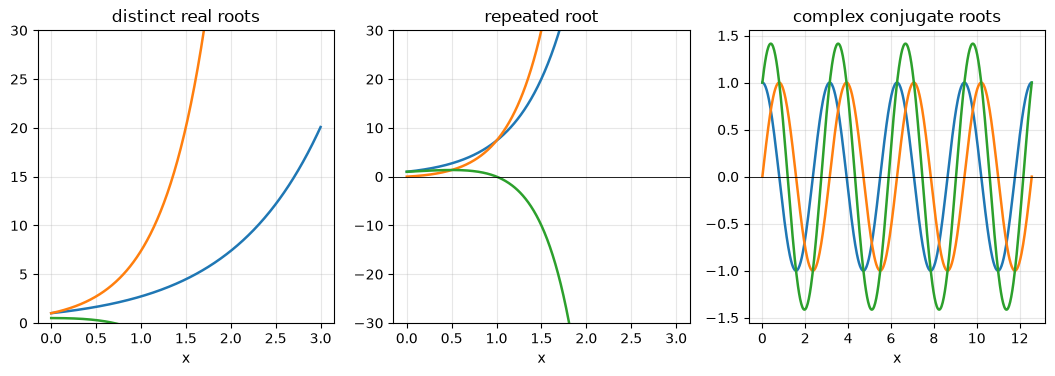

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
xx = np.linspace(0, 3, 400)

for c1, c2 in [(1, 0), (0, 1), (1, -0.5)]:
    axes[0].plot(xx, c1 * np.exp(xx) + c2 * np.exp(2 * xx), lw=1.8)
axes[0].set_title("distinct real roots")
axes[0].set_ylim(0, 30)

for c1, c2 in [(1, 0), (0, 1), (1, -1)]:
    axes[1].plot(xx, (c1 + c2 * xx) * np.exp(2 * xx), lw=1.8)
axes[1].set_title("repeated root")
axes[1].set_ylim(-30, 30)

xo = np.linspace(0, 4 * np.pi, 500)
for c1, c2 in [(1, 0), (0, 1), (1, 1)]:
    axes[2].plot(xo, c1 * np.cos(2 * xo) + c2 * np.sin(2 * xo), lw=1.8)
axes[2].set_title("complex conjugate roots")

for ax in axes:
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", lw=0.6)
plt.show()

In [4]:
X = sp.symbols("X")


def wronskian(f, g):
    return sp.simplify(f * sp.diff(g, X) - g * sp.diff(f, X))


print("e^x, e^2x   :", wronskian(sp.exp(X), sp.exp(2 * X)))
print("e^2x, x e^2x:", wronskian(sp.exp(2 * X), X * sp.exp(2 * X)))
print("sin, cos    :", wronskian(sp.sin(X), sp.cos(X)))
print("e^x, 3e^x   :", wronskian(sp.exp(X), 3 * sp.exp(X)))

e^x, e^2x   : exp(3*X)
e^2x, x e^2x: exp(4*X)
sin, cos    : -1
e^x, 3e^x   : 0


In [5]:
from scipy.integrate import solve_ivp

L = 1.0


def shoot(k, n=400):
    def f(x, y):
        return [y[1], -(k**2) * y[0]]

    s = solve_ivp(f, [0, L], [0.0, 1.0], t_eval=np.linspace(0, L, n), rtol=1e-12, atol=1e-14)
    return s.t, s.y[0]


for k in [1.0, 2.0, 3.0, np.pi, 4.0, 5.0, 6.0, 2 * np.pi, 7.0]:
    print(f"k = {k:6.4f}   y(L) = {shoot(k)[1][-1]:+.6f}")

k = 1.0000   y(L) = +0.841471
k = 2.0000   y(L) = +0.454649
k = 3.0000   y(L) = +0.047040
k = 3.1416   y(L) = -0.000000
k = 4.0000   y(L) = -0.189201
k = 5.0000   y(L) = -0.191785
k = 6.0000   y(L) = -0.046569
k = 6.2832   y(L) = +0.000000
k = 7.0000   y(L) = +0.093855


In [6]:
for n in range(1, 5):
    k = n * np.pi
    print(f"k = {k:9.6f}  (= {n} pi)   y(L) = {shoot(k)[1][-1]:+.2e}")

k =  3.141593  (= 1 pi)   y(L) = -2.81e-15
k =  6.283185  (= 2 pi)   y(L) = +3.13e-15
k =  9.424778  (= 3 pi)   y(L) = -3.04e-15
k = 12.566371  (= 4 pi)   y(L) = +3.22e-15


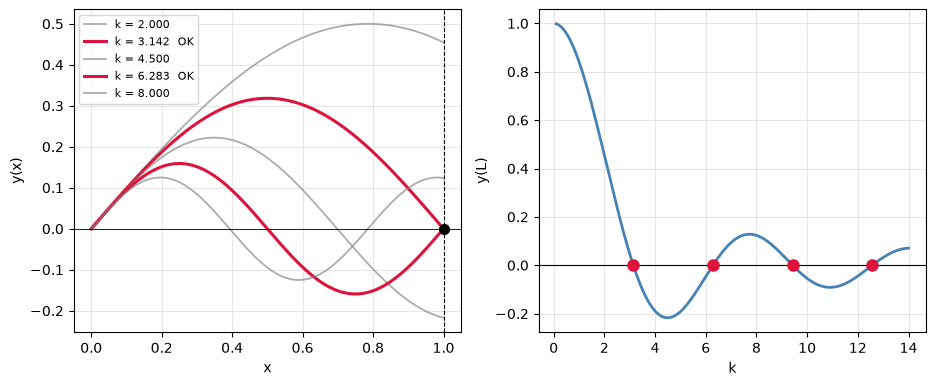

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

for k, ok in [
    (2.0, False),
    (np.pi, True),
    (4.5, False),
    (2 * np.pi, True),
    (8.0, False),
]:
    xs, ys = shoot(k)
    a1.plot(
        xs,
        ys,
        lw=2.2 if ok else 1.3,
        color="crimson" if ok else "gray",
        alpha=1.0 if ok else 0.65,
        label=f"k = {k:.3f}" + ("  OK" if ok else ""),
    )
a1.axhline(0, color="black", lw=0.6)
a1.axvline(L, color="black", lw=0.8, ls="--")
a1.plot([L], [0], "o", color="black", ms=7)
a1.set_xlabel("x")
a1.set_ylabel("y(x)")
a1.legend(fontsize=8)
a1.grid(alpha=0.3)

ks = np.linspace(0.1, 14, 600)
a2.plot(ks, [shoot(k, n=2)[1][-1] for k in ks], lw=2, color="steelblue")
a2.axhline(0, color="black", lw=0.8)
for n in range(1, 5):
    a2.plot([n * np.pi], [0], "o", color="crimson", ms=8, zorder=5)
a2.set_xlabel("k")
a2.set_ylabel("y(L)")
a2.grid(alpha=0.3)

plt.show()

In [8]:
def second_derivative_matrix(N, h):
    return (np.eye(N, k=1) - 2 * np.eye(N) + np.eye(N, k=-1)) / h**2


N = 2000
h = L / (N + 1)

eigvals = np.linalg.eigvalsh(-second_derivative_matrix(N, h))

print("행렬에서 얻은 k          :", np.round(np.sqrt(eigvals[:4]), 5))
print("이론값 n*pi/L (n=1...4) :", [round(n * np.pi / L, 5) for n in range(1, 5)])

행렬에서 얻은 k          : [ 3.14159  6.28318  9.42477 12.56635]
이론값 n*pi/L (n=1...4) : [3.14159, 6.28319, 9.42478, 12.56637]
